In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
from pathlib import Path

folder = "C:/Users/JesseOnu/fpl sql rework/gws"

test = os.listdir(folder)[0]
print(f"testing with file: {test}")
df_test = pd.read_csv(f"{folder}/{test}")
print(df_test.head())
print(df_test.columns)

testing with file: 2526gw1.csv
   player_id  player_code  gameweek  fixture_id                          name  \
0          1       154561         1           9             David Raya Martín   
1          2       109745         1           9    Kepa Arrizabalaga Revuelta   
2          3       463748         1           9                     Karl Hein   
3          4       551221         1           9                 Tommy Setford   
4          5       226597         1           9  Gabriel dos Santos Magalhães   

       web_name  position_id  selected_by_percent  value  team_id  ...  \
0          Raya            1                 34.4    6.0        1  ...   
1  Arrizabalaga            1                  0.4    4.1        1  ...   
2          Hein            1                  0.2    4.0        1  ...   
3       Setford            1                  0.2    3.9        1  ...   
4       Gabriel            2                 42.7    7.1        1  ...   

   influence creativity threat  in_dr

In [2]:
cols_to_keep = ['player_code', 'gameweek', 
       'web_name', 'position_id',
       'minutes', 'goals_scored', 'assists', 'clean_sheets',
       'yellow_cards', 'red_cards', 'bonus', 'bps', 'total_points', 'xG', 'xA',
       'xGI', 'DefCon',
       'corners_indirect_freekicks_order', 'direct_freekicks_order',
       'penalties_order', 'season']

In [3]:
def load_season_data(path):
    files = os.listdir(path)

    dataframes = []
    for f in files:
        filepath = os.path.join(path, f)
        df = pd.read_csv(filepath, usecols = cols_to_keep)
        dataframes.append(df)

    df_combined = pd.concat(dataframes, ignore_index=True)

    return df_combined.reset_index(drop=True)

In [4]:
df = load_season_data(folder)

In [5]:
df = df[df['season']==2627]

In [6]:
stats = df.groupby(['player_code', 'web_name']).agg({'minutes': 'sum', 'goals_scored':'sum','assists': 'sum', 'xA':'sum','xG':'sum','xA':'sum', 'xGI':'sum', 'DefCon':'sum','position_id':'max', 'corners_indirect_freekicks_order':'max','direct_freekicks_order':'max','penalties_order':'max'}) 

In [7]:
#stats = stats[stats['season']== 2627]
maxmins = stats['minutes'].max()
stats['min_perc'] = 100*(stats['minutes']/maxmins).round(2)
stats = stats[stats['min_perc'] >= 30]

In [8]:
print(stats.shape)
stats

(256, 12)


,,minutes,goals_scored,assists,xA,xG,xGI,DefCon,position_id,corners_indirect_freekicks_order,direct_freekicks_order,penalties_order,min_perc
player_code,web_name,,,,,,,,,,,,
17761,Tarkowski,360,1,0,0.03,0.17,0.20,39,2,NaN,NaN,NaN,100.0
54469,Smith,360,0,0,0.07,0.01,0.08,21,2,NaN,NaN,NaN,100.0
60307,Groß,360,2,3,0.61,1.66,2.27,21,3,1.0,1.0,1.0,100.0
80201,Leno,360,0,0,0.00,0.00,0.00,0,1,NaN,NaN,NaN,100.0
83299,Dunk,360,1,0,0.09,0.03,0.12,23,2,NaN,3.0,NaN,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
610799,Vuskovic,347,1,0,0.07,0.46,0.53,31,2,NaN,NaN,NaN,96.0
611695,Yalcouyé,231,2,0,0.27,1.42,1.69,18,3,NaN,NaN,NaN,64.0
647850,Kostoulas,278,1,2,0.05,1.17,1.22,23,4,NaN,NaN,NaN,77.0


In [9]:
stats['xGp90'] = (90* stats['xG'] / stats['minutes']).fillna(0).round(2)
stats['xAp90'] = (90* stats['xA'] / stats['minutes']).fillna(0).round(2)
stats['GoalInv'] =  stats['goals_scored'] + stats['assists'] 
stats['GIp90'] = (90* stats['GoalInv'] / stats['minutes']).fillna(0).round(2)
stats['xGIp90'] = (90* stats['xGI'] / stats['minutes']).fillna(0).round(2)
stats['defconp90'] = (90* stats['DefCon'] / stats['minutes']).fillna(0).round(2)
stats['xgisafe'] = stats['xGI'].apply(lambda x: x if x>0 else 0.01)
stats['xasafe'] = stats['xA'].apply(lambda x: x if x>0 else 0.01)
stats['xgi_performance_pct'] = ((stats['GoalInv'] - stats['xgisafe']) / stats['xgisafe']).round(2)
stats['xa_performance_pct'] = ((stats['assists'] - stats['xasafe']) / stats['xasafe']).round(2)

In [10]:
stats

,,minutes,goals_scored,assists,xA,xG,xGI,DefCon,position_id,corners_indirect_freekicks_order,direct_freekicks_order,...,xGp90,xAp90,GoalInv,GIp90,xGIp90,defconp90,xgisafe,xasafe,xgi_performance_pct,xa_performance_pct
player_code,web_name,,,,,,,,,,,,,,,,,,,,,
17761,Tarkowski,360,1,0,0.03,0.17,0.20,39,2,NaN,NaN,...,0.04,0.01,1,0.25,0.05,9.75,0.20,0.03,4.00,-1.00
54469,Smith,360,0,0,0.07,0.01,0.08,21,2,NaN,NaN,...,0.00,0.02,0,0.00,0.02,5.25,0.08,0.07,-1.00,-1.00
60307,Groß,360,2,3,0.61,1.66,2.27,21,3,1.0,1.0,...,0.42,0.15,5,1.25,0.57,5.25,2.27,0.61,1.20,3.92
80201,Leno,360,0,0,0.00,0.00,0.00,0,1,NaN,NaN,...,0.00,0.00,0,0.00,0.00,0.00,0.01,0.01,-1.00,-1.00
83299,Dunk,360,1,0,0.09,0.03,0.12,23,2,NaN,3.0,...,0.01,0.02,1,0.25,0.03,5.75,0.12,0.09,7.33,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610799,Vuskovic,347,1,0,0.07,0.46,0.53,31,2,NaN,NaN,...,0.12,0.02,1,0.26,0.14,8.04,0.53,0.07,0.89,-1.00
611695,Yalcouyé,231,2,0,0.27,1.42,1.69,18,3,NaN,NaN,...,0.55,0.11,2,0.78,0.66,7.01,1.69,0.27,0.18,-1.00
647850,Kostoulas,278,1,2,0.05,1.17,1.22,23,4,NaN,NaN,...,0.38,0.02,3,0.97,0.39,7.45,1.22,0.05,1.46,39.00


In [20]:
stats =stats.reset_index()
features = ['xGp90','xAp90','defconp90','xgi_performance_pct', 'xa_performance_pct']
scaler = MinMaxScaler()
normalized_values = scaler.fit_transform(stats[features])

normalized_df = pd.DataFrame(
    normalized_values,
    columns = features
)
 
normalized_df['player_code'] = stats['player_code'].values
normalized_df['web_name'] = stats['web_name'].values
normalized_df['position_id'] = stats['position_id'].values
normalized_df

,xGp90,xAp90,defconp90,xgi_performance_pct,xa_performance_pct,player_code,web_name,position_id
0,0.048193,0.017241,0.555872,0.550055,0.0000,17761,Tarkowski,2
1,0.000000,0.034483,0.299316,0.000000,0.0000,54469,Smith,2
2,0.506024,0.258621,0.299316,0.242024,0.0984,60307,Groß,3
3,0.000000,0.000000,0.000000,0.000000,0.0000,80201,Leno,1
4,0.012048,0.034483,0.327822,0.916392,0.0000,83299,Dunk,2
...,...,...,...,...,...,...,...,...
251,0.144578,0.034483,0.458381,0.207921,0.0000,610799,Vuskovic,2
252,0.662651,0.189655,0.399658,0.129813,0.0000,611695,Yalcouyé,3
253,0.457831,0.034483,0.424743,0.270627,0.8000,647850,Kostoulas,4
254,0.024096,0.000000,0.456100,0.000000,0.0000,651426,Canvot,2


In [21]:
   print(stats.columns)

Index(['level_0', 'index', 'player_code', 'web_name', 'minutes',
       'goals_scored', 'assists', 'xA', 'xG', 'xGI', 'DefCon', 'position_id',
       'corners_indirect_freekicks_order', 'direct_freekicks_order',
       'penalties_order', 'min_perc', 'xGp90', 'xAp90', 'GoalInv', 'GIp90',
       'xGIp90', 'defconp90', 'xgisafe', 'xasafe', 'xgi_performance_pct',
       'xa_performance_pct'],
      dtype='object')


In [22]:
forwards = normalized_df[normalized_df['position_id']==3]
forwards

,xGp90,xAp90,defconp90,xgi_performance_pct,xa_performance_pct,player_code,web_name,position_id
2,0.506024,0.258621,0.299316,0.242024,0.0984,60307,Groß,3
5,0.012048,0.413793,0.655644,0.110011,0.0212,84450,Xhaka,3
7,0.132530,0.068966,0.407640,0.000000,0.0000,88894,Barkley,3
12,0.000000,0.000000,0.616876,0.000000,0.0000,101282,Crooks,3
18,0.240964,0.086207,0.350627,0.113311,0.1000,122806,McGinn,3
...,...,...,...,...,...,...,...,...
244,0.421687,0.068966,0.559863,0.000000,0.0000,596777,Dorgu,3
249,0.024096,0.034483,0.412201,0.000000,0.0000,608227,Stroud,3
250,0.024096,0.051724,0.504561,0.523652,0.1666,609873,Armstrong,3
252,0.662651,0.189655,0.399658,0.129813,0.0000,611695,Yalcouyé,3


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

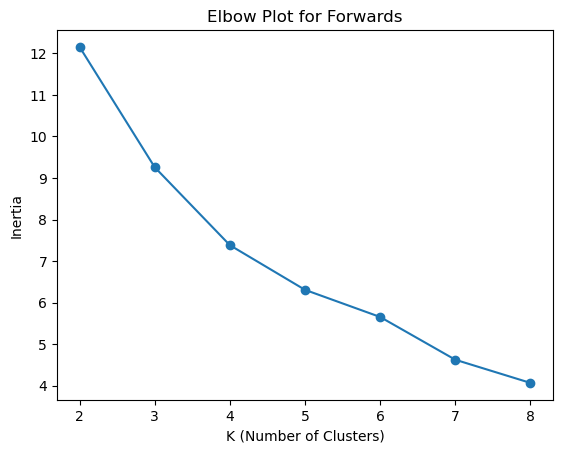

In [27]:
clustering_features = forwards[['xGp90','xAp90','defconp90','xgi_performance_pct','xa_performance_pct']].copy()

inertias = []
k_vals = []

for k in range(2,9):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(clustering_features)
    inertias.append(kmeans.inertia_)
    k_vals.append(k)

import matplotlib.pyplot as plt
plt.plot(k_vals, inertias, 'o-')
plt.xlabel('K (Number of Clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Forwards')
plt.show()

In [28]:
print("Clustering features columns:", clustering_features.columns.tolist())
print("Clustering features shape:", clustering_features.shape)
print("Centroids shape:", final_kmeans.cluster_centers_.shape)

Clustering features columns: ['xGp90', 'xAp90', 'defconp90', 'xgi_performance_pct', 'xa_performance_pct']
Clustering features shape: (111, 5)
Centroids shape: (6, 7)


In [29]:
final_kmeans = KMeans(n_clusters=6, random_state=42)
cluster_assignments= final_kmeans.fit_predict(clustering_features)

forwards['cluster'] = cluster_assignments

centroids = final_kmeans.cluster_centers_
centroid_df = pd.DataFrame(
    centroids,
    columns=['xGp90', 'xAp90', 'defconp90','xgi_performance_pct','xa_performance_pct'])
centroid_df['cluster'] = range(6)
centroid_df
    

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\JesseOnu\AppData\Local\Temp\ipykernel_38684\1807267586.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forwards['cluster'] = cluster_assignments


,xGp90,xAp90,defconp90,xgi_performance_pct,xa_performance_pct,cluster
0,0.297189,0.518391,0.355872,0.120865,0.024387,0
1,0.059036,0.114655,0.726767,0.035424,0.002380,1
2,0.087780,0.320197,0.558845,0.194169,0.048343,2
3,0.139224,0.124521,0.370911,0.046351,0.007293,3
4,0.106928,0.075431,0.531286,0.609736,0.300325,4
5,0.680054,0.304598,0.358926,0.118567,0.021978,5


In [30]:
print(forwards['cluster'].value_counts().sort_index())

cluster
0    15
1    20
2    14
3    45
4     8
5     9
Name: count, dtype: int64


In [41]:
cluster_names = {
    0: "Attacking Playmaker (Mid)",
    1: "DefCon (Mid)",
    2: "Creative + DefCon Potential (Mid)",
    3: "Well Rounded (Mid)",
    4: "Box to Box (Mid)",
    5: "Attacking Threat (Mid)"
}
forwards['archetype'] = forwards['cluster'].map(cluster_names)
forwards[forwards['cluster'] ==5]

C:\Users\JesseOnu\AppData\Local\Temp\ipykernel_38684\3654503408.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forwards['archetype'] = forwards['cluster'].map(cluster_names)


,xGp90,xAp90,defconp90,xgi_performance_pct,xa_performance_pct,player_code,web_name,position_id,cluster,archetype
2,0.506024,0.258621,0.299316,0.242024,0.0984,60307,Groß,3,5,Attacking Threat (Mid)
20,0.686747,0.482759,0.327822,0.128713,0.0176,141746,B.Fernandes,3,5,Attacking Threat (Mid)
53,0.530120,0.362069,0.527936,0.132013,0.0000,201658,Tavernier,3,5,Attacking Threat (Mid)
64,0.807229,0.620690,0.331243,0.088009,0.0454,209244,Foden,3,5,Attacking Threat (Mid)
88,0.927711,0.206897,0.442987,0.100110,0.0000,223340,Saka,3,5,Attacking Threat (Mid)
148,0.843373,0.241379,0.313569,0.099010,0.0364,446008,Mbeumo,3,5,Attacking Threat (Mid)
189,0.638554,0.362069,0.265678,0.038504,0.0000,484420,E.Le Fée,3,5,Attacking Threat (Mid)
235,0.518072,0.017241,0.322121,0.108911,0.0000,571779,Palacios,3,5,Attacking Threat (Mid)
252,0.662651,0.189655,0.399658,0.129813,0.0000,611695,Yalcouyé,3,5,Attacking Threat (Mid)
